In [1]:
! pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---

In [25]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from xgboost import XGBRegressor
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

In [3]:
df=pd.read_csv('Housing.csv')

In [4]:
print(df)

        price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no   

    hotwaterheating aircond

In [5]:
df.shape

(545, 13)

In [6]:
#check for missing values 
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
#statistical measures
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
#understanding the correlation b/w various features 
#1.positive 
#2.negative

In [11]:
print(df.dtypes)

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [12]:
correlation = df.select_dtypes(include='number').corr()

<Axes: >

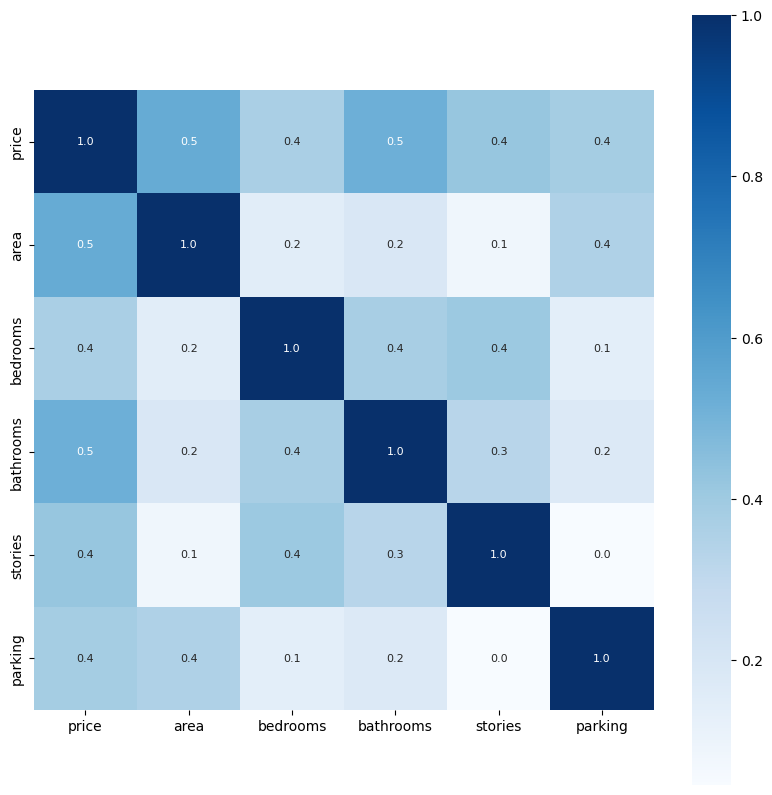

In [13]:
#constructing heatmap to understand correlation
plt.figure(figsize=(10,10))
sns.heatmap(correlation,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Blues')

In [35]:

df_encoded = df.copy()
le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

In [44]:
x=df_encoded.drop(['price'],axis=1)
y=df_encoded['price']

In [45]:
x.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,0
1,8960,4,4,4,1,0,0,0,1,3,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,1
3,7500,4,2,2,1,0,1,0,1,3,1,0
4,7420,4,1,2,1,1,1,0,1,2,0,0


In [46]:
y.head()

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64

In [65]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=3)

In [66]:
print(x.shape,x_train.shape,x_test.shape)

(545, 12) (381, 12) (164, 12)


In [67]:
#model train
#xgboostregressor

In [75]:
#loading the model
model=XGBRegressor(   max_depth=2,
    n_estimators=50,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.6,
    reg_alpha=1.0,
    reg_lambda=5.0,
    min_child_weight=5  )

In [76]:
model.fit(x_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [77]:
#evaluation
#prediction on training data


In [78]:
#accuracy for prediction on training data 
train_data_predict=model.predict(x_train)

In [79]:
print(train_data_predict)

[4.3831930e+06 7.1761950e+06 4.2121215e+06 6.5024320e+06 5.4525150e+06
 4.1518278e+06 5.3558575e+06 5.6819910e+06 5.2653665e+06 5.2585675e+06
 3.6209938e+06 3.9438375e+06 7.3033285e+06 3.7583595e+06 4.5426600e+06
 3.6969838e+06 5.3168660e+06 3.1869540e+06 5.0514880e+06 5.5902845e+06
 4.0932922e+06 4.2209765e+06 4.2388925e+06 5.7756535e+06 4.3042590e+06
 7.2454250e+06 4.8896590e+06 5.8904880e+06 3.4811375e+06 6.1266930e+06
 3.6969092e+06 4.1488872e+06 3.9273685e+06 5.2949610e+06 5.1191410e+06
 6.0814910e+06 4.6037320e+06 6.3584145e+06 3.5747615e+06 3.4923255e+06
 6.9014235e+06 3.5267830e+06 5.5947690e+06 5.8633895e+06 5.9465575e+06
 3.3372140e+06 3.7583595e+06 4.3121450e+06 4.7796150e+06 3.9800620e+06
 6.6333175e+06 4.0913395e+06 3.8415658e+06 3.5531898e+06 4.6956165e+06
 4.1742232e+06 4.7423070e+06 5.0351315e+06 4.3683950e+06 4.8877115e+06
 3.8552522e+06 3.7699390e+06 4.6124540e+06 3.4811375e+06 3.6625262e+06
 3.4825978e+06 3.3372140e+06 3.5170552e+06 4.6766995e+06 4.4991800e+06
 6.845

In [80]:
#rsquarederror mse mae
score_1=metrics.r2_score(y_train,train_data_predict)
score_2=metrics.mean_absolute_error(y_train,train_data_predict)
print(score_1)
print(score_2)

0.6555339097976685
795660.6875


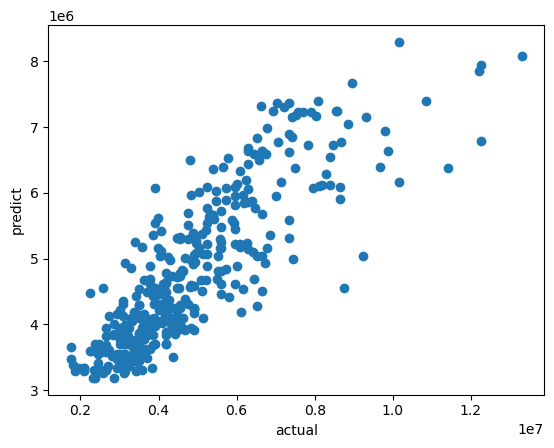

In [82]:
plt.scatter(y_train,train_data_predict)
plt.xlabel('actual')
plt.ylabel('predict')
plt.show()

In [81]:
# Test set scores (the real measure of performance)
test_data_predict = model.predict(x_test)

test_r2  = metrics.r2_score(y_test, test_data_predict)
test_mae = metrics.mean_absolute_error(y_test, test_data_predict)

print("Train R²:", score_1)
print("Test  R²:", test_r2)
print("Train MAE:", score_2)
print("Test  MAE:", test_mae)

Train R²: 0.6555339097976685
Test  R²: 0.5422772765159607
Train MAE: 795660.6875
Test  MAE: 855132.3125
